# 📘 Clase 3 · Notebook 4 — Proceso autorregresivo AR(p)

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 5**.

| | |
|---|---|
| **Datos** | `foot_traffic.csv` — tráfico peatonal semanal promedio en una tienda (1000 semanas) |
| **Tiempo estimado en casa** | 30 min |
| **¿Se vio en clase?** | ✅ Parcialmente — **Demo 3** (Bloque 2): solo ACF vs. PACF (celdas 1–11) |

### 🎯 Al terminar este notebook podrás…
1. Definir un proceso **AR(p)** como una regresión de la serie sobre su propio pasado.
2. Entender la **autocorrelación parcial (PACF)** y usarla para elegir *p*.
3. Pronosticar con un AR(p) y compararlo contra baselines.

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH05/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH05
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **Proceso autorregresivo AR(p)**

$$y_t = C + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$$

Es una **regresión lineal de la serie sobre sus propios valores pasados** (“auto”-regresión). A diferencia del MA, aquí lo que se arrastra son los **valores**, no las sorpresas.

Analogía: la **inercia**. Una tienda con mucha gente la semana pasada probablemente tenga mucha gente esta semana; el efecto se va diluyendo, pero **nunca se corta de golpe**.

🔑 **Firma del AR(p):** la **ACF decae lentamente** (no se corta) y la **PACF se corta** después del lag *p*.

In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df = pd.read_csv('../data/foot_traffic.csv')

df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


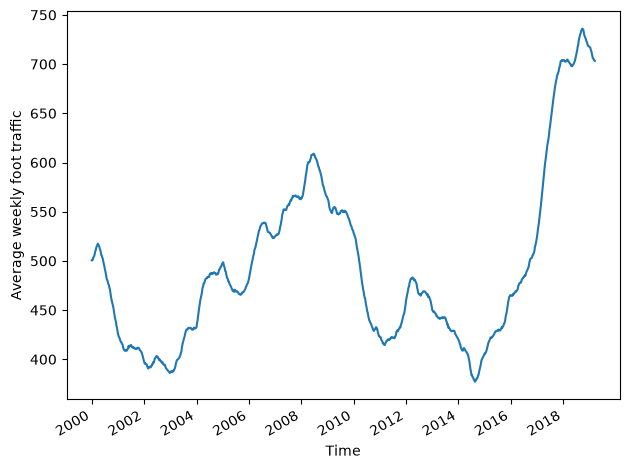

In [4]:
fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH05_F01_peixeiro.png', dpi=300)

🧭 ¿Es estacionaria? Prueba ADF.

In [5]:
ADF_result = adfuller(df['foot_traffic'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.1758885999240727
p-value: 0.6838808917896197


🔎 p-valor ≈ 0.68 → no estacionaria.

🧭 No → diferenciamos una vez.

In [6]:
foot_traffic_diff = np.diff(df['foot_traffic'], n=1)

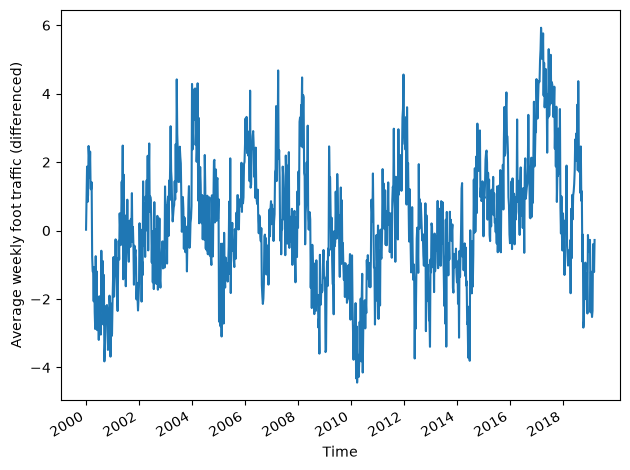

In [7]:
fig, ax = plt.subplots()

ax.plot(foot_traffic_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic (differenced)')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH05_F05_peixeiro.png', dpi=300)

In [8]:
ADF_result = adfuller(foot_traffic_diff)

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -5.268231347422053
p-value: 6.369317654781036e-06


🔎 p-valor ≈ 0.000006 → la diferenciada es estacionaria. ✅

🧭 Miramos la ACF de la serie diferenciada.

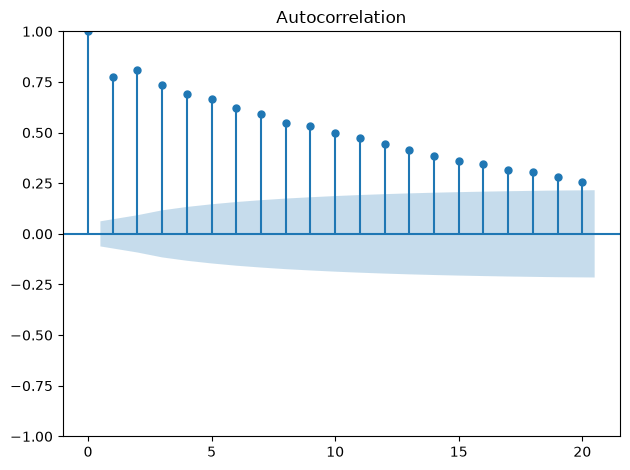

In [9]:
plot_acf(foot_traffic_diff, lags=20);

plt.tight_layout()

plt.savefig('figures/CH05_F06_peixeiro.png', dpi=300)

🔎 La ACF **decae lentamente** con forma de onda y hay muchos lags significativos: **no se corta** → **no es un MA puro**. Sospechamos un AR.

## Simulation 

💡 **Autocorrelación parcial (PACF).** Mide la correlación entre $y_t$ y $y_{t-k}$ **quitando el efecto de los rezagos intermedios**.

Analogía: el parecido entre un nieto y su abuelo. Parte del parecido llega *a través del padre*. La PACF pregunta: *¿cuánto se parece el nieto al abuelo **una vez descontado lo que ya explica el padre**?*

🧭 Para practicar, primero simulamos un AR(2) conocido: $y_t = 0.33\,y_{t-1} + 0.50\,y_{t-2} + \varepsilon_t$.

⚠️ Detalle de `ArmaProcess`: los coeficientes AR se escriben **con el signo invertido** e incluyendo un 1 al inicio: `[1, -0.33, -0.50]`.

In [10]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

np.random.seed(42)

ma2 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.50])

AR2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

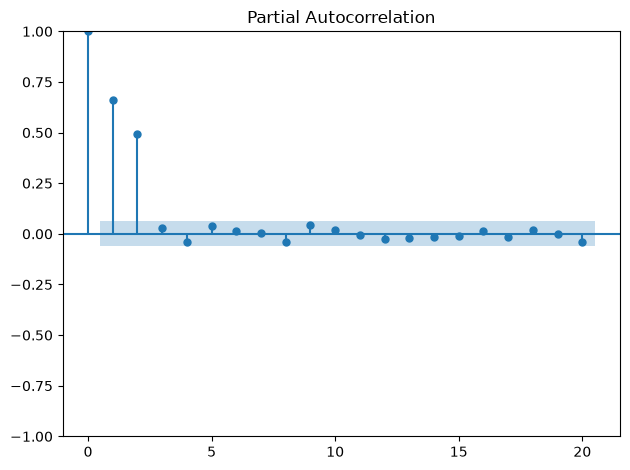

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(AR2_process, lags=20);

plt.tight_layout()

plt.savefig('figures/CH05_F07_peixeiro.png', dpi=300)

🔎 En la serie simulada AR(2), la PACF muestra lags 1 y 2 significativos y **luego se corta**. Exactamente el orden que usamos para simularla. ✅

🧭 Ahora, la PACF de nuestra serie real diferenciada.

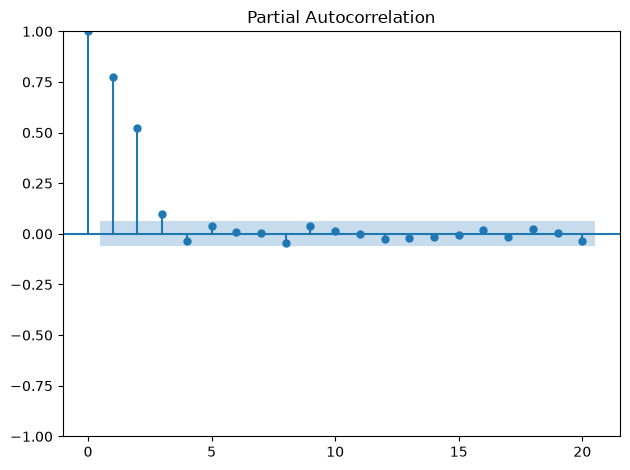

In [12]:
plot_pacf(foot_traffic_diff, lags=20);

plt.tight_layout()

plt.savefig('figures/CH05_F08_peixeiro.png', dpi=300)

🔎 Lags 1, 2 y 3 significativos y luego corte → modelo **AR(3)**.

🧭 El **test son las últimas 52 semanas** (un año): 947 semanas de train y 52 de test.

In [13]:
df_diff = pd.DataFrame({'foot_traffic_diff': foot_traffic_diff})

train = df_diff[:-52]
test = df_diff[-52:]

print(len(train))
print(len(test))

947
52


In [14]:
test

,foot_traffic_diff
947,-0.776601
948,-0.574631
949,-0.890697
950,-0.283552
951,-1.830685
952,0.635514
953,-0.807623
954,1.040389
955,0.326728
956,1.028235


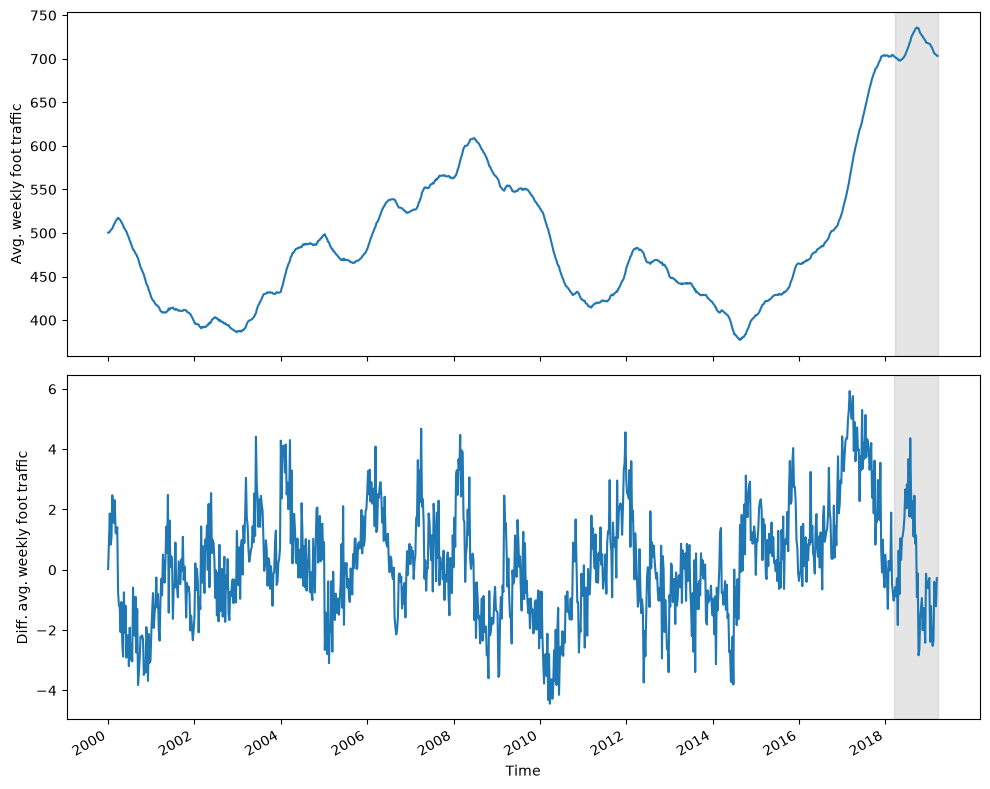

In [15]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 8))

ax1.plot(df['foot_traffic'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Avg. weekly foot traffic')
ax1.axvspan(948, 1000, color='#808080', alpha=0.2)

ax2.plot(df_diff['foot_traffic_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Diff. avg. weekly foot traffic')
ax2.axvspan(947, 999, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH05_F09_peixeiro.png', dpi=300)

💡 **Pronóstico rodante (*rolling forecast*).** En vez de pronosticar los 52 puntos del test de una sola vez, avanzamos de a `WINDOW` pasos:
1. Entrenamos con todo lo conocido hasta el momento *i*.
2. Pronosticamos los siguientes `WINDOW` pasos.
3. “Llegan” los datos reales de esos pasos, los agregamos al entrenamiento y repetimos.

Analogía: el pronóstico del clima se actualiza cada día con la observación nueva; nadie pronostica todo el mes de una sola vez.

Aquí `WINDOW = 1`: pronosticamos una semana, “observamos” el valor real y volvemos a entrenar.

🧭 La función `rolling_forecast` implementa tres métodos para compararlos en igualdad de condiciones: `mean` (media), `last` (último valor) y el modelo estadístico. Dentro del modelo: `get_prediction(0, i + window - 1)` genera predicciones hasta el final de la ventana y `.iloc[-window:]` se queda solo con las **fuera de muestra** (las del futuro).

In [16]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'mean':
        pred_mean = []
        
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'AR':
        pred_AR = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(3,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_AR.extend(oos_pred)
            
        return pred_AR

In [17]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_AR = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'AR')

test['pred_mean'] = pred_mean
test['pred_last_value'] = pred_last_value
test['pred_AR'] = pred_AR

test.head()

,foot_traffic_diff,pred_mean,pred_last_value,pred_AR
947,-0.776601,0.213270,-1.021893,-0.719714
948,-0.574631,0.212226,-0.776601,-0.814547
949,-0.890697,0.211397,-0.574631,-0.664738
950,-0.283552,0.210237,-0.890697,-0.641469
951,-1.830685,0.209717,-0.283552,-0.579279


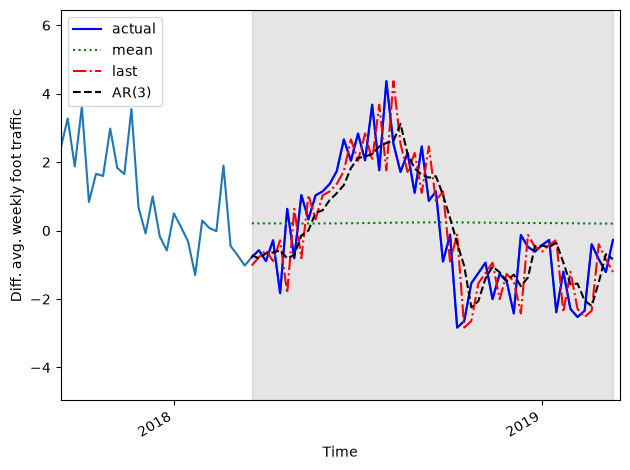

In [18]:
fig, ax = plt.subplots()

ax.plot(df_diff['foot_traffic_diff'])
ax.plot(test['foot_traffic_diff'], 'b-', label='actual')
ax.plot(test['pred_mean'], 'g:', label='mean')
ax.plot(test['pred_last_value'], 'r-.', label='last')
ax.plot(test['pred_AR'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Diff. avg. weekly foot traffic')

ax.axvspan(947, 998, color='#808080', alpha=0.2)

ax.set_xlim(920, 999)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH05_F10_peixeiro.png', dpi=300)

In [19]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['foot_traffic_diff'], test['pred_mean'])
mse_last = mean_squared_error(test['foot_traffic_diff'], test['pred_last_value'])
mse_AR = mean_squared_error(test['foot_traffic_diff'], test['pred_AR'])

print(mse_mean, mse_last, mse_AR)

3.1079979374701447 1.448730118495964 0.9242479168759974


🔎 MSE: media ≈ 3.11, último valor ≈ 1.45, **AR(3) ≈ 0.92**. El AR(3) gana.

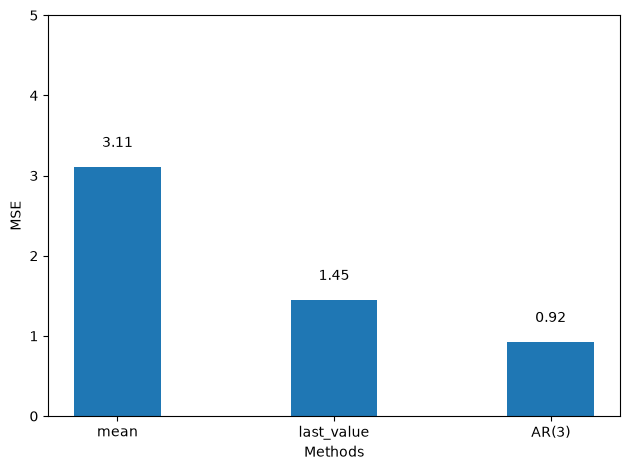

In [20]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'AR(3)']
y = [mse_mean, mse_last, mse_AR]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

💡 **Volver a la escala original (invertir la diferenciación).** El modelo pronosticó **cambios** (serie diferenciada), pero al negocio le interesan **niveles** (ventas reales). Como diferenciar es restar, deshacerlo es **sumar acumuladamente**: valor inicial + suma acumulada de los cambios pronosticados (`cumsum`).

In [21]:
df['pred_foot_traffic'] = np.nan

# 🛠️ .loc en lugar de asignación encadenada (compatible con pandas 2.x / 3.x)
df.loc[948:, 'pred_foot_traffic'] = df['foot_traffic'].iloc[948] + test['pred_AR'].cumsum().values

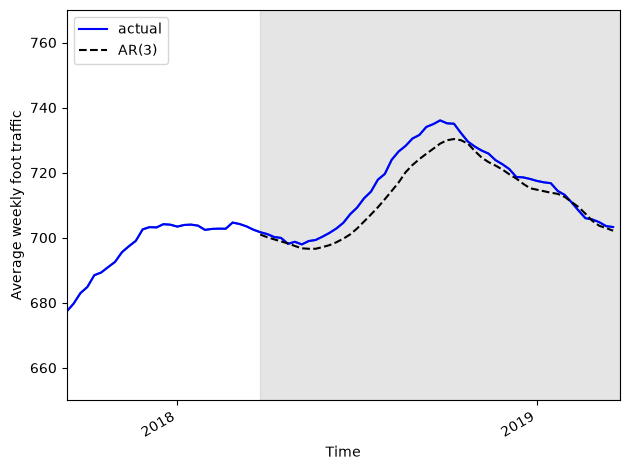

In [22]:
fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.plot(df['foot_traffic'], 'b-', label='actual')
ax.plot(df['pred_foot_traffic'], 'k--', label='AR(3)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

ax.axvspan(948, 1000, color='#808080', alpha=0.2)

ax.set_xlim(920, 1000)
ax.set_ylim(650, 770)

plt.xticks([936, 988],[2018, 2019])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH05_F11_peixeiro.png', dpi=300)

🧭 Error en la escala original con el **MAE**.

In [23]:
from sklearn.metrics import mean_absolute_error

mae_AR_undiff = mean_absolute_error(df['foot_traffic'][948:], df['pred_foot_traffic'][948:])

print(mae_AR_undiff)

3.478033556709877


🔎 MAE ≈ 3.48 personas por semana, en la escala original del tráfico peatonal.

---
## ✅ Resumen
| | MA(q) | AR(p) |
|---|---|---|
| El presente depende de… | sorpresas pasadas | valores pasados |
| ACF | **se corta** después de *q* | decae lentamente |
| PACF | decae lentamente | **se corta** después de *p* |

🔗 **Siguiente:** ¿y si **ni la ACF ni la PACF** se cortan? → modelo **ARMA(p,q)** y un procedimiento general basado en el **AIC** (Capítulo 6).

### 🏠 Ejercicios para casa
`CH05_exercises_solution.ipynb`: simula un AR(2) y un AR(p) de orden mayor, identifica *p* con la PACF y pronostica.

### 🧠 Autoevaluación
- Explica con tus palabras la diferencia entre ACF y PACF.
- Si la PACF se corta en el lag 4 y la ACF decae, ¿qué modelo propones?
